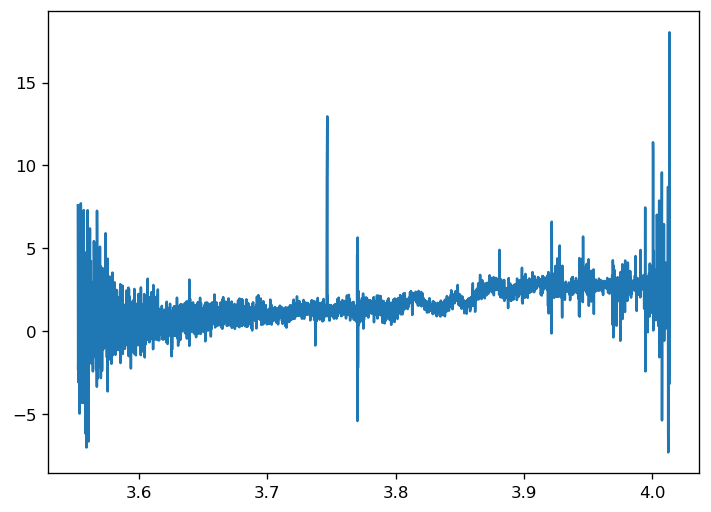

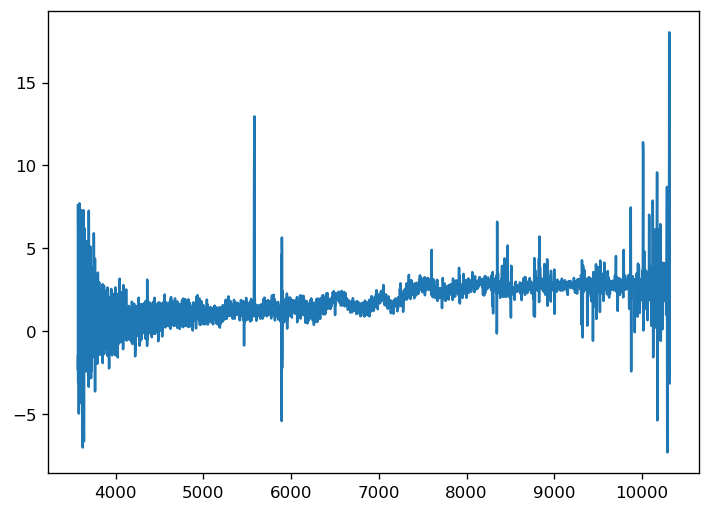

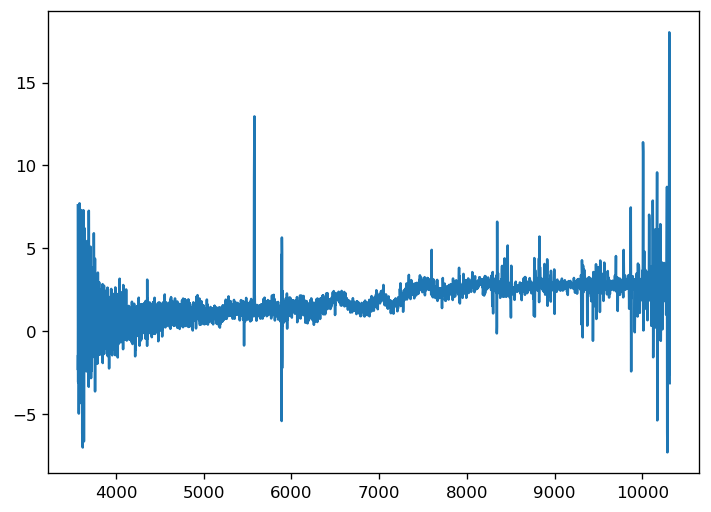

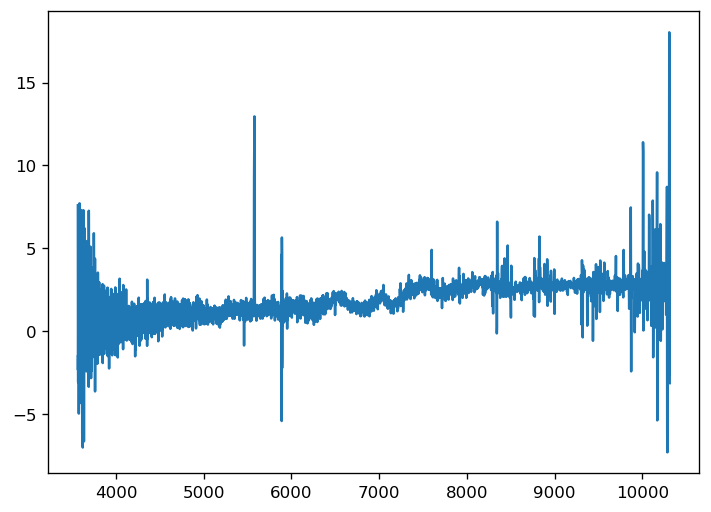

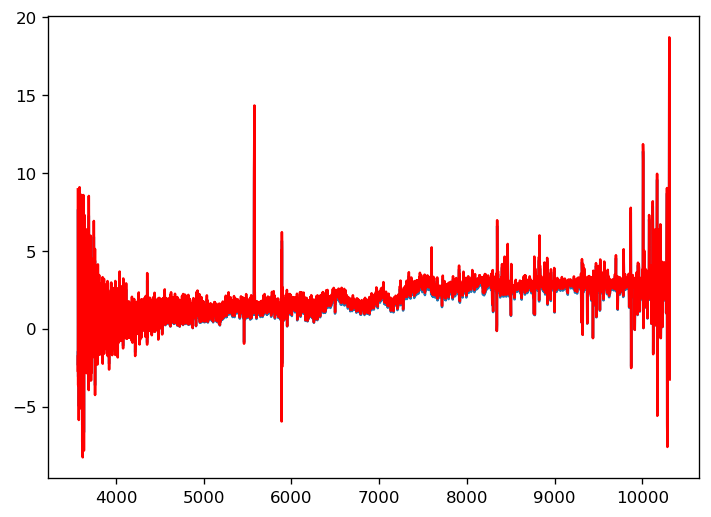

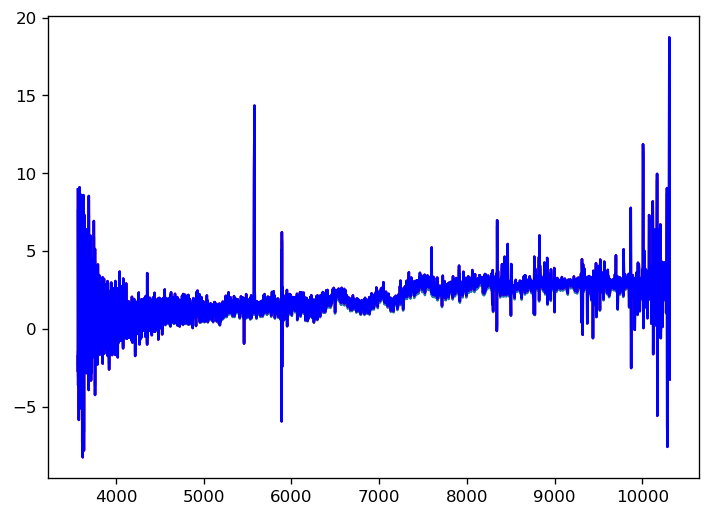

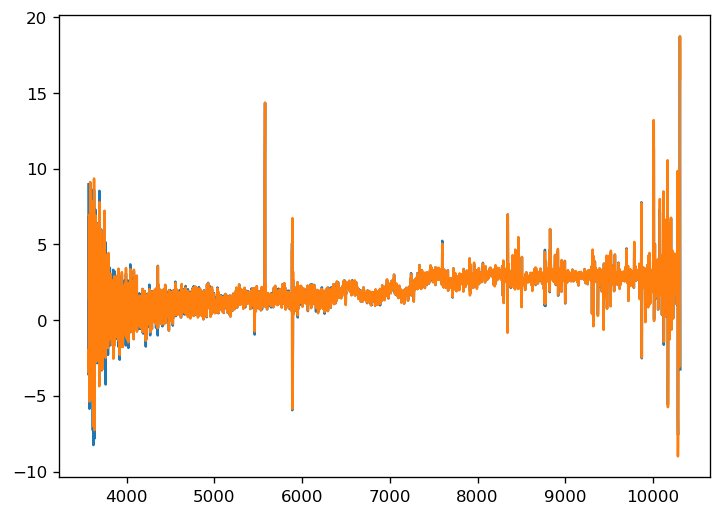

In [4]:
import os
import sys
import glob


from pathlib import Path
from astropy.io import fits
import numpy as np
from numpy import savetxt
import matplotlib.pyplot as plt
from PyAstronomy import pyasl
from scipy.interpolate import interp1d
from astropy import units as u
from astropy.coordinates import SkyCoord
#install dustmaps from https://github.com/gregreen/dustmaps
from dustmaps.sfd import SFDQuery

Spec_NAME = "spec-3817-55277-0001.fits"





hdu = fits.open('/home/hollman/DataHII/'+Spec_NAME)


##############################################################
#Read the header

header01 = hdu[2].data

zz = header01.Z
RA = header01.RA
DEC = header01.DEC

c = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs')
c.galactic

sfd = SFDQuery()
ebv01 = sfd(c.galactic)

##############################################################
#Read the spectra, flux and wavelength

spec = hdu[1].data

flux = spec.FLUX
loglam = spec.LOGLAM

plt.figure(figsize=(7,5), dpi=120)
plt.plot(loglam,flux)
plt.show()

##############################################################
#wavelength in linear angstroms

lambda01 = 10**loglam

plt.figure(figsize=(7,5), dpi=120)
plt.plot(lambda01,flux)
plt.show()

##############################################################
#Change vacuum to air wavelength

waveobs = lambda01 / (1.0 + 2.735182E-4 + 131.4182 / lambda01**2 + 2.76249E8 / lambda01**4)

plt.figure(figsize=(7,5), dpi=120)
plt.plot(waveobs,flux)
plt.show()

##############################################################
#redshift correction

wave = waveobs/(1.0+zz)

plt.figure(figsize=(7,5), dpi=120)
plt.plot(wave,flux)
plt.show()

##############################################################
#Unredding the spectra

fluxUnred = pyasl.unred(wave, flux, ebv=ebv01, R_V=3.1)

plt.figure(figsize=(7,5), dpi=120)
plt.plot(wave,flux)
plt.plot(wave,fluxUnred,color='red')
plt.show()

##############################################################
#cosmoiogical flux corrextion

flux_final = fluxUnred*(1.0+zz)**3

plt.figure(figsize=(7,5), dpi=120)
plt.plot(wave,flux)
plt.plot(wave,fluxUnred,color='red')
plt.plot(wave,flux_final,color='blue')
plt.show()

##############################################################
#Change the wavelength to starlight input

wave_in = int(wave[2])             #initial wavelength
wave_fin = int(wave[len(wave)-2])  #final wavelength

wave_new = np.arange(wave_in, wave_fin, 1)

flux_interpolate = interp1d(wave, flux_final, kind='quadratic')
flux_starlight = flux_interpolate(wave_new)

plt.figure(figsize=(7,5), dpi=120)
plt.plot(wave,flux_final)
plt.plot(wave_new,flux_starlight)
plt.show()

##############################################################
#Crate an output array

table = list(zip(wave_new, flux_starlight))

# Save the file
savetxt(Spec_NAME + '.tex', table, fmt='%8.4f', delimiter='    ')